# **Comparative Content Analysis of Major Streaming Platforms**

## Platforms and Dataset Source

- [Netflix](https://www.kaggle.com/datasets/shivamb/netflix-shows)
- [Amazon Prime](https://www.kaggle.com/datasets/shivamb/amazon-prime-movies-and-tv-shows)
- [Disney+](https://www.kaggle.com/datasets/shivamb/disney-movies-and-tv-shows)

## Project Overview

This project compares the content catalogs of **Netflix**, **Amazon Prime**, and **Disney+** using publicly available streaming datasets from **Kaggle**. The analysis focuses on data quality assessment, feature engineering, and comparative analysis to examine differences in content volume, release years, genres, ratings, durations, production countries, cast members, and directors across platforms. The objective is to identify similarities and differences in each platform's content library while demonstrating practical data cleaning, visualization, and analytical techniques using Python.

## Install Libraries

In [ ]:
!pip install pandas matplotlib seaborn scikit-learn numpy

## Import Libraries

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

## Load Datasets

In [3]:
amazon_df = pd.read_csv(r'dataset/amazon_prime_titles.csv')
disney_df = pd.read_csv(r'dataset/disney_plus_titles.csv')
netflix_df = pd.read_csv(r'dataset/netflix_titles.csv')

## Customize Graph Display

In [4]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 140

def format_plot(title, xlabel, ylabel):
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True, alpha=0.3)
    plt.savefig(f"images/{title}.png", dpi=300, bbox_inches="tight")
    plt.tight_layout()
    plt.show()

## Data Overview

In [5]:
print(f"{amazon_df.info()}\n")    # Amazon
print(f"{disney_df.info()}\n")    # Disney
print(f"{netflix_df.info()}\n")   # Netflix

<class 'pandas.DataFrame'>
RangeIndex: 9668 entries, 0 to 9667
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       9668 non-null   str  
 1   type          9668 non-null   str  
 2   title         9668 non-null   str  
 3   director      7585 non-null   str  
 4   cast          8435 non-null   str  
 5   country       672 non-null    str  
 6   date_added    155 non-null    str  
 7   release_year  9668 non-null   int64
 8   rating        9331 non-null   str  
 9   duration      9668 non-null   str  
 10  listed_in     9668 non-null   str  
 11  description   9668 non-null   str  
dtypes: int64(1), str(11)
memory usage: 906.5 KB
None

<class 'pandas.DataFrame'>
RangeIndex: 1450 entries, 0 to 1449
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       1450 non-null   str  
 1   type          1450 non-null   str  
 2   title     

## Data Quality Assessment

### Missing Values

In [6]:
# Average of missing values
for name, df in [("Amazon", amazon_df), ("Disney", disney_df), ("Netflix", netflix_df)]:
    pct_null = (df.isnull().sum() / df.shape[0] * 100).round(2)
    print(f"{name} \n{pct_null}\n{df.shape}\n")

Amazon 
show_id          0.00
type             0.00
title            0.00
director        21.55
cast            12.75
country         93.05
date_added      98.40
release_year     0.00
rating           3.49
duration         0.00
listed_in        0.00
description      0.00
dtype: float64
(9668, 12)

Disney 
show_id          0.00
type             0.00
title            0.00
director        32.62
cast            13.10
country         15.10
date_added       0.21
release_year     0.00
rating           0.21
duration         0.00
listed_in        0.00
description      0.00
dtype: float64
(1450, 12)

Netflix 
show_id          0.00
type             0.00
title            0.00
director        29.91
cast             9.37
country          9.44
date_added       0.11
release_year     0.00
rating           0.05
duration         0.03
listed_in        0.00
description      0.00
dtype: float64
(8807, 12)



### Duplicate Check

In [7]:
print(f"Amazon : {amazon_df.duplicated().sum()}")
print(f"Disney : {disney_df.duplicated().sum()}")
print(f"Netflix : {netflix_df.duplicated().sum()}")

Amazon : 0
Disney : 0
Netflix : 0


## Dataset Preview

In [8]:
amazon_df.head(2)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,The Grand Seduction,Don McKellar,"Brendan Gleeson, Taylor Kitsch, Gordon Pinsent",Canada,"March 30, 2021",2014,NaN,113 min,"Comedy, Drama",A small fishing village must procure a local d...
1,s2,Movie,Take Care Good Night,Girish Joshi,"Mahesh Manjrekar, Abhay Mahajan, Sachin Khedekar",India,"March 30, 2021",2018,13+,110 min,"Drama, International",A Metro Family decides to fight a Cyber Crimin...


In [9]:
disney_df.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Duck the Halls: A Mickey Mouse Christmas Special,"Alonso Ramirez Ramos, Dave Wasson","Chris Diamantopoulos, Tony Anselmo, Tress MacN...",NaN,"November 26, 2021",2016,TV-G,23 min,"Animation, Family",Join Mickey and the gang as they duck the halls!
1,s2,Movie,Ernest Saves Christmas,John Cherry,"Jim Varney, Noelle Parker, Douglas Seale",NaN,"November 26, 2021",1988,PG,91 min,Comedy,Santa Claus passes his magic bag to a new St. ...


In [10]:
netflix_df.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."


## Data Cleaning

In [11]:
# Add column that identify their platforms
amazon_df.insert(1, "platform", "Amazon")
disney_df.insert(1, "platform", "Disney")
netflix_df.insert(1, "platform", "Netflix")

In [12]:
# Merge all the datasets
streaming_df = pd.concat(
    [amazon_df, disney_df, netflix_df],
    ignore_index=True
)

streaming_df.head(3)

,show_id,platform,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Amazon,Movie,The Grand Seduction,Don McKellar,"Brendan Gleeson, Taylor Kitsch, Gordon Pinsent",Canada,"March 30, 2021",2014,NaN,113 min,"Comedy, Drama",A small fishing village must procure a local d...
1,s2,Amazon,Movie,Take Care Good Night,Girish Joshi,"Mahesh Manjrekar, Abhay Mahajan, Sachin Khedekar",India,"March 30, 2021",2018,13+,110 min,"Drama, International",A Metro Family decides to fight a Cyber Crimin...
2,s3,Amazon,Movie,Secrets of Deception,Josh Webber,"Tom Sizemore, Lorenzo Lamas, Robert LaSardo, R...",United States,"March 30, 2021",2017,NaN,74 min,"Action, Drama, Suspense",After a man discovers his wife is cheating on ...


In [13]:
# Remove index
streaming_df.drop(columns="show_id", inplace=True)
streaming_df.reset_index(drop=True, inplace=True)

In [14]:
# Fill missing and null values
streaming_df['director'] = streaming_df['director'].fillna("Unknown")
streaming_df['title'] = streaming_df['title'].fillna("Unknown")
streaming_df['cast'] = streaming_df['cast'].fillna("Unknown")
streaming_df['country'] = streaming_df['country'].fillna("Unknown")
streaming_df['duration'] = streaming_df['duration'].fillna("Unknown")
streaming_df['rating'] = streaming_df['rating'].fillna("Unknown")

In [15]:
# Correct misplaced duration values stored in the rating column
mask = streaming_df['rating'].str.contains('min', na=False)

streaming_df.loc[mask, 'duration'] = streaming_df.loc[mask, 'rating']
streaming_df.loc[mask, 'rating'] = "Unknown"

streaming_df.loc[mask, ['rating', 'duration']]

,rating,duration
16659,Unknown,74 min
16912,Unknown,84 min
16931,Unknown,66 min


In [16]:
# Standardize date columns for consistent date operations
streaming_df['date_added'] = streaming_df['date_added'].str.strip()
streaming_df['date_added'] = pd.to_datetime(streaming_df['date_added'])

streaming_df['release_year'] = (
    pd.to_datetime(streaming_df['release_year'], format='%Y')
    .dt.strftime('%Y')
)

## Feature Engineering

In [17]:
# Extract the month and year from the date_added column
streaming_df.insert(
    7, 
    "month_added", 
    streaming_df['date_added'].dt.strftime('%b')
)

streaming_df.insert(
    8, 
    "year_added", 
    streaming_df['date_added'].dt.strftime('%Y')
) 

# Create a numerical feature representing movie duration or TV Show seasons
streaming_df.insert(
    10, 
    'duration_numeric', 
    streaming_df['duration']
    .str.extract(r'(\d+)', expand=False).astype(int)
)

In [18]:
# Verify remaining missing values after cleaning
(streaming_df.isnull().sum() / streaming_df.shape[0] * 100).round(2)

platform             0.00
type                 0.00
title                0.00
director             0.00
cast                 0.00
country              0.00
date_added          47.81
month_added         47.81
year_added          47.81
release_year         0.00
duration_numeric     0.00
rating               0.00
duration             0.00
listed_in            0.00
description          0.00
dtype: float64

## Comparative Analysis

C:\Users\User\AppData\Local\Temp\ipykernel_23520\2412631724.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


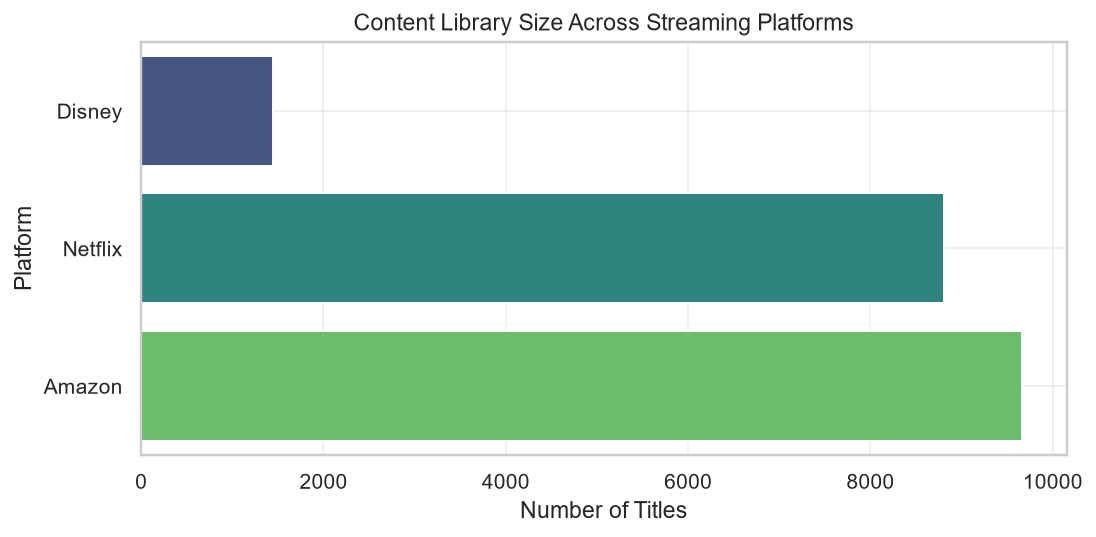

In [19]:
# Count the total number of titles available on each streaming platform

platform_title_counts = streaming_df['platform'].value_counts().reset_index(name='count').sort_index(ascending=False)

plt.figure(figsize=(8,4))

sns.barplot(
    data=platform_title_counts,
    x='count',
    y='platform',
    palette='viridis'
)

format_plot(
    "Content Library Size Across Streaming Platforms",
    "Number of Titles",
    "Platform"
)

**Amazon Prime Video** has the largest catalog, with close to **9,500 titles**, while **Netflix** follows with about **8,500**. **Disney+** is much smaller, with roughly **1,800 titles**. The gap points to a broader content strategy at Amazon and Netflix, while Disney+ is operating with a narrower and more curated library.

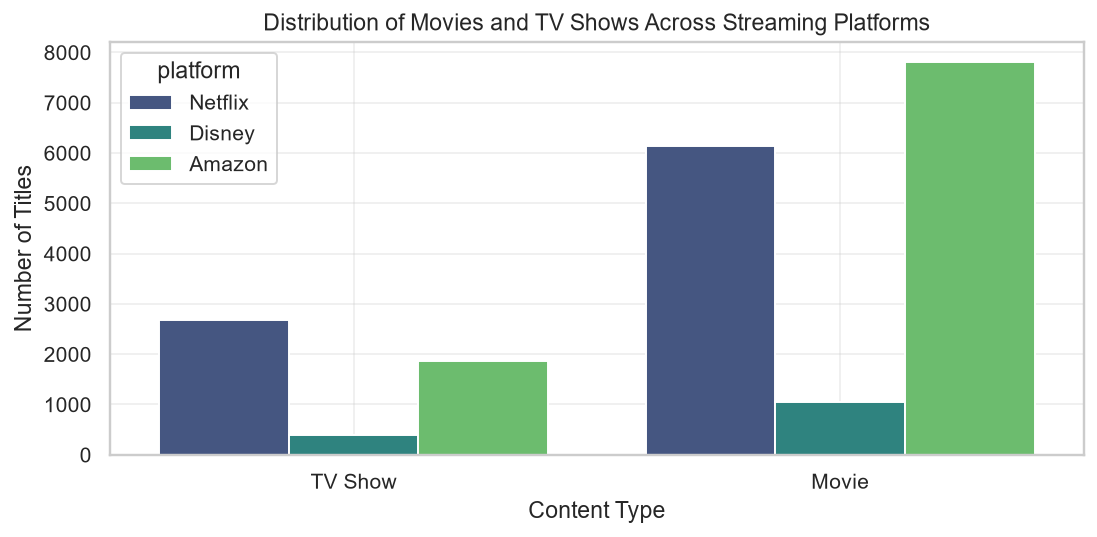

In [20]:
# Compare the distribution of Movies and TV Shows across platforms

platform_content_counts = streaming_df.groupby(['platform','type']).size().reset_index(name='count').sort_index(ascending=False)

# Visualize
plt.figure(figsize=(8,4))

sns.barplot(
    data=platform_content_counts,
    x='type',
    y='count',
    hue='platform',
    palette='viridis'
)

format_plot(
    "Distribution of Movies and TV Shows Across Streaming Platforms",
    "Content Type",
    "Number of Titles"
)

Movies make up the **majority of content** on all three platforms. **Netflix** has a noticeably **stronger TV-show presence** than Amazon and Disney+, which gives it a stronger position in series-based viewing. This mix supports Netflix's stronger identity in serialized entertainment.

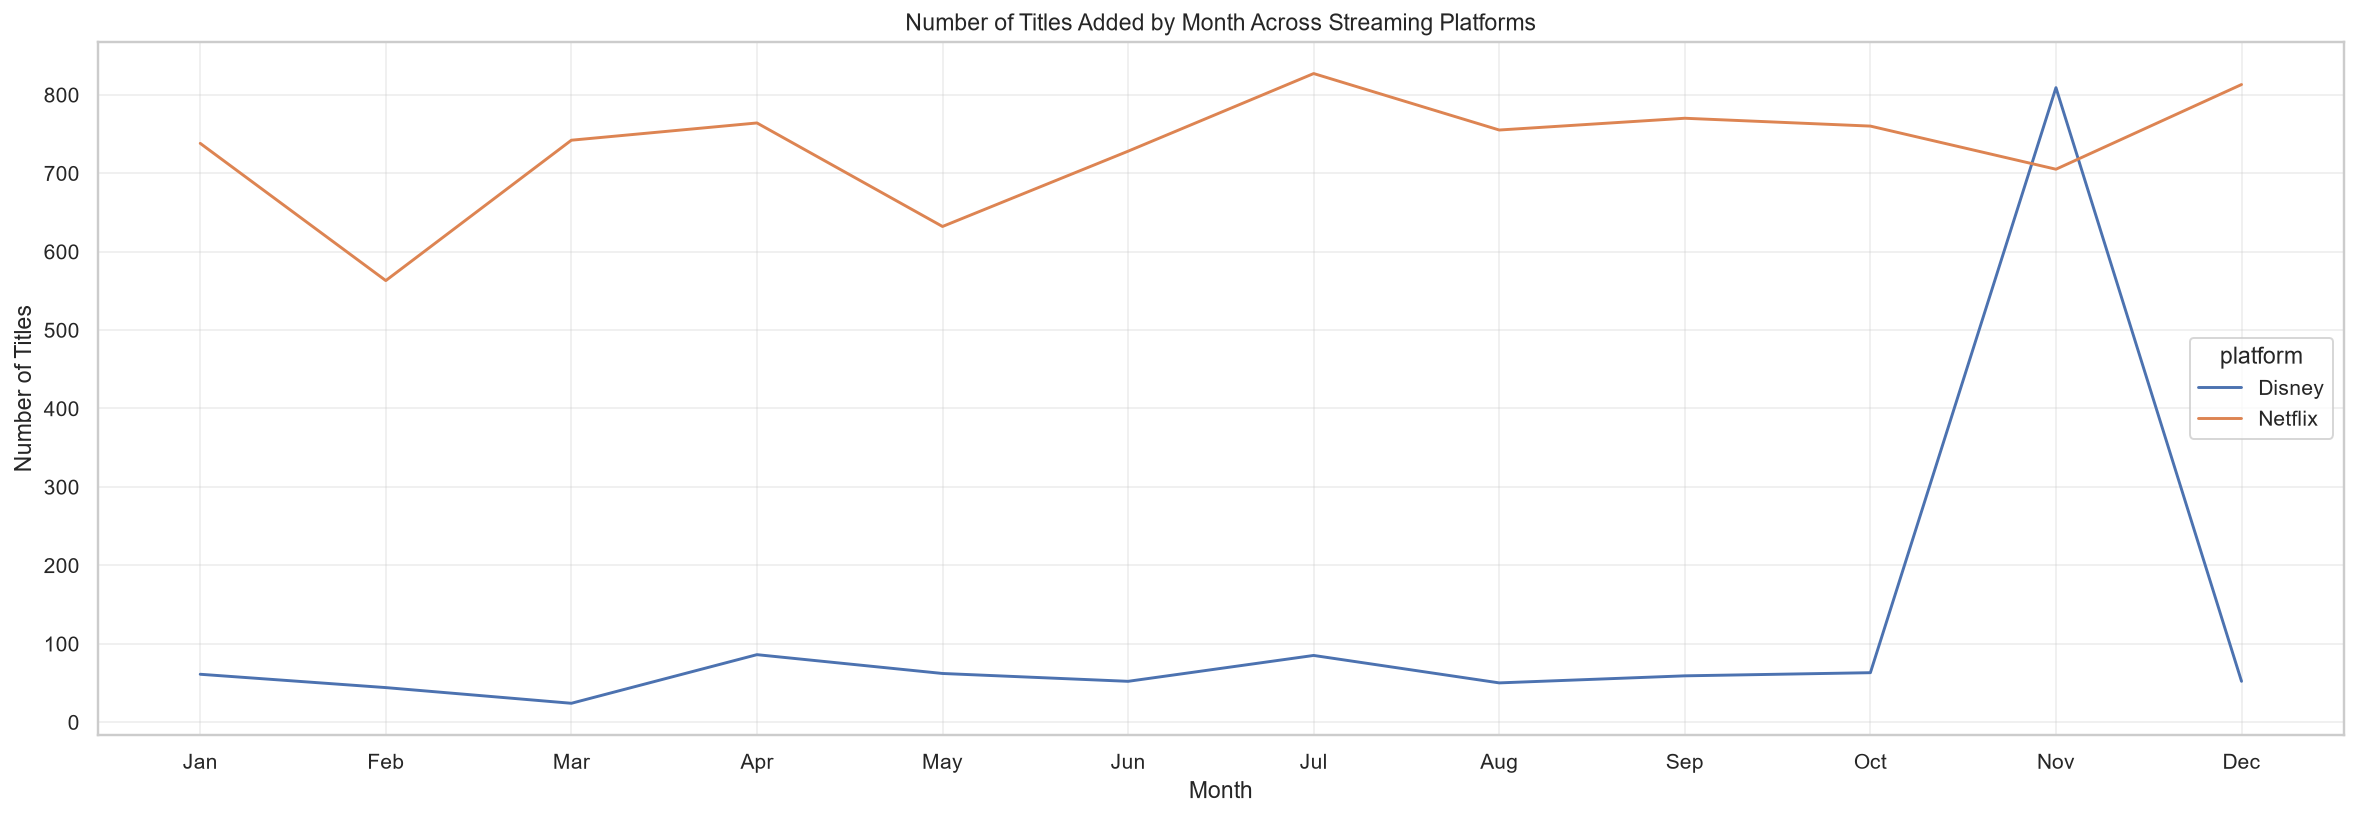

In [21]:
# Titles Added by Month
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

monthly_added_titles = (
    streaming_df.query('platform != "Amazon"')
    .groupby(['platform', 'month_added'])
    .size()
    .reset_index(name='count')
)

# Force correct month order
monthly_added_titles['month_added'] = pd.Categorical(
    monthly_added_titles['month_added'], 
    categories=month_order, 
    ordered=True
)

# Visualize
plt.figure(figsize=(17, 6))

sns.lineplot(
    data=monthly_added_titles,
    x='month_added',
    y='count',
    hue='platform'
)

format_plot(
    'Number of Titles Added by Month Across Streaming Platforms',
    'Month',
    'Number of Titles'
)

**Netflix** shows steady additions across the year, while **Disney+** has a very small catalog outside of a large spike in **November**. This suggests **Netflix** maintains a more consistent monthly release schedule, and **Disney+** has a more concentrated add pattern in specific periods. 

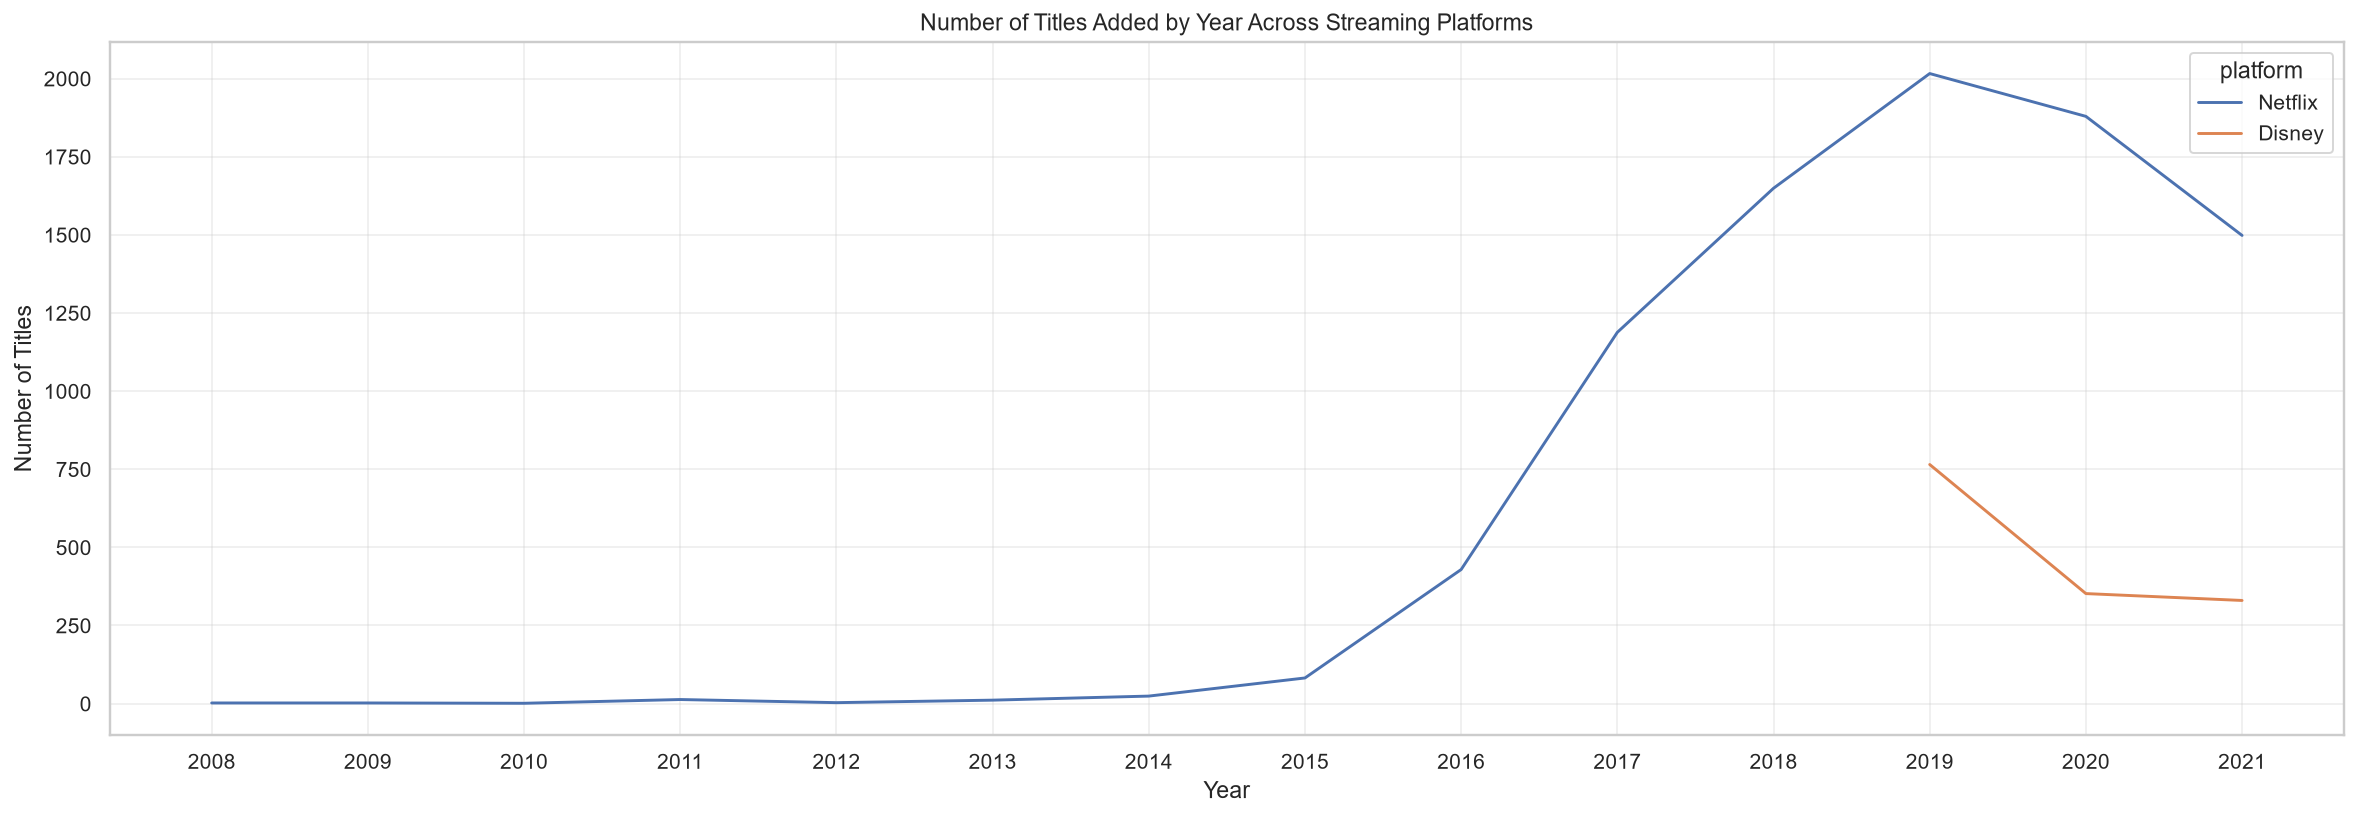

In [22]:
# Titles Added by Year

year_added_titles = (
    streaming_df.query('platform != "Amazon"')
    .groupby(['platform', 'year_added'])
    .size()
    .reset_index(name='count')
    .sort_values('year_added')
)

# Visualize
plt.figure(figsize=(17, 6))

sns.lineplot(
    data=year_added_titles,
    x='year_added',
    y='count',
    hue='platform'
)

format_plot(
    'Number of Titles Added by Year Across Streaming Platforms',
    'Year',
    'Number of Titles'
)


Netflix grew fast from 2013 to 2017, peaking at 1,750, but then dropped sharply to 150 by 2021 — suggesting it lost momentum after its early dominance. Disney stayed low throughout, only showing small rises in 2020 (350) and 2021 (300), indicating it entered the streaming game late and is still building its foothold.

> Note: **Amazon Prime** was excluded because **98.40%** of its **``date_added``** data is missing, making it unreliable for a fair year‑over‑year comparison.

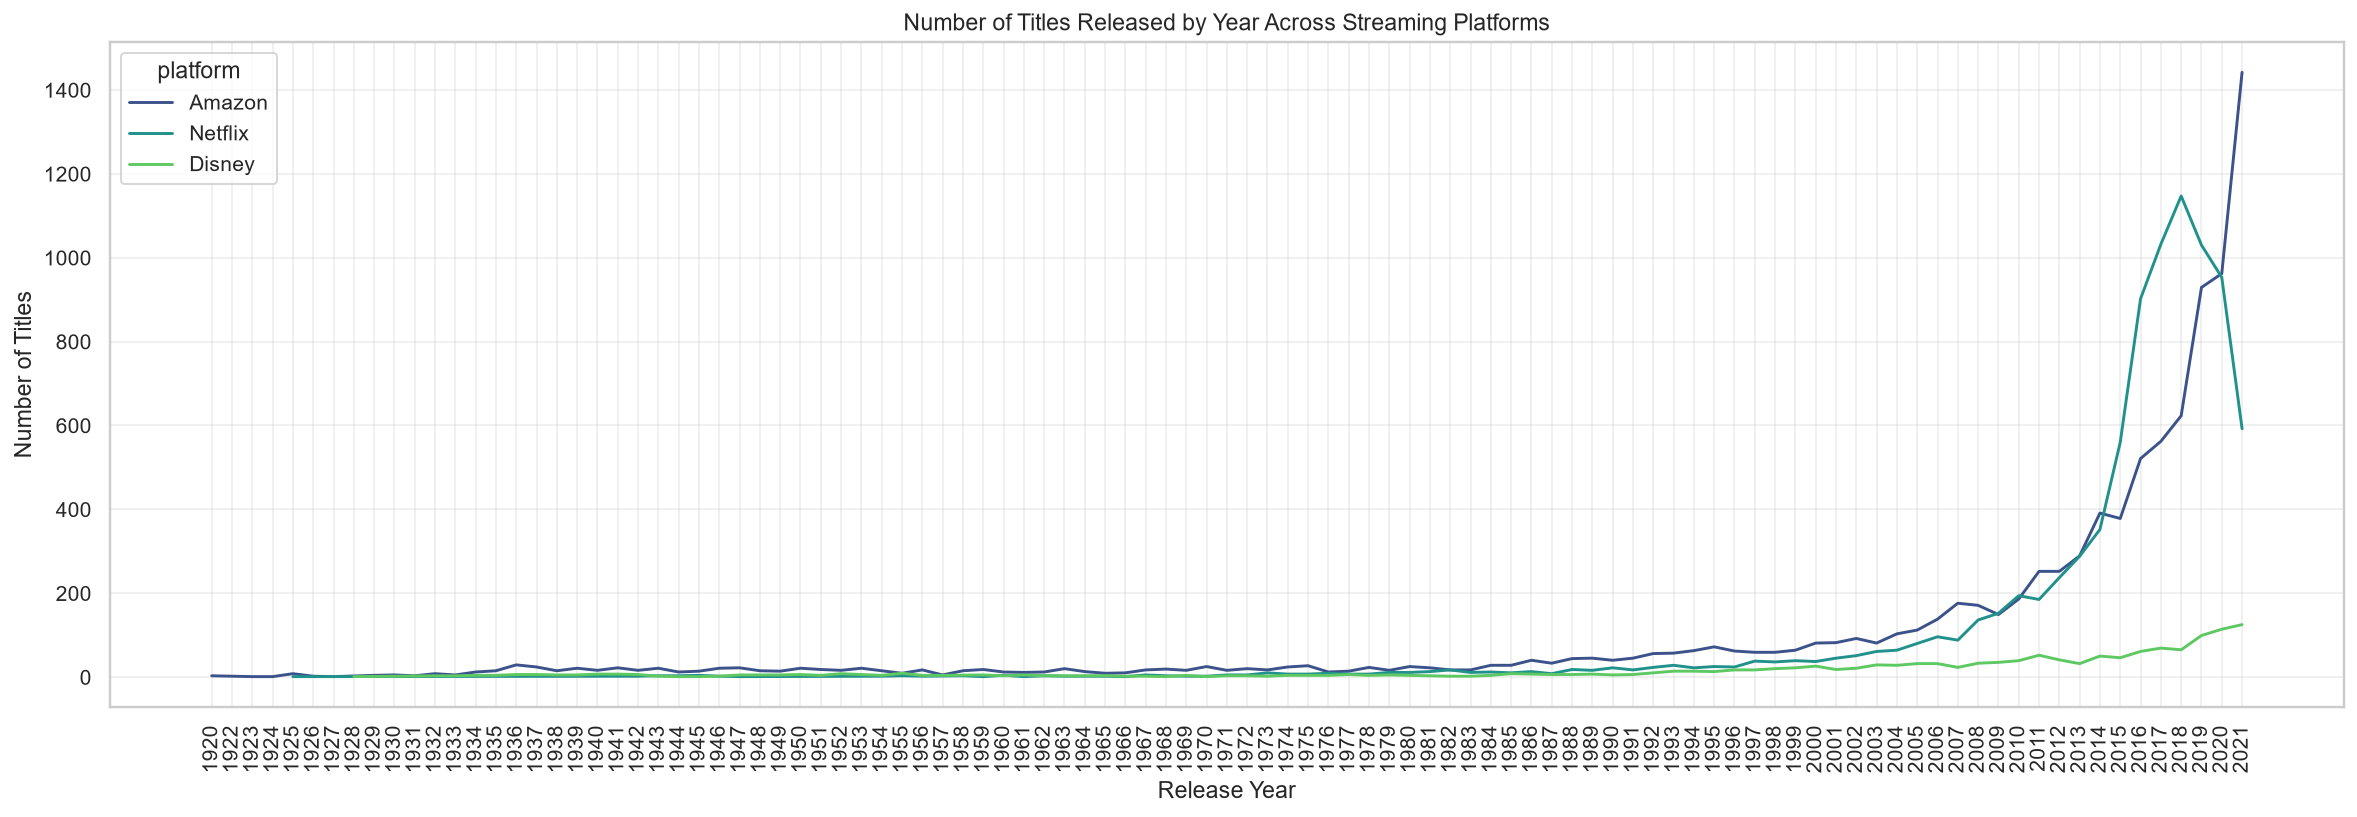

In [23]:
# Count the number of titles released each year for every platform

count_platform = streaming_df.groupby(['platform','release_year']).size().reset_index(name='count').sort_values('release_year', ascending=True)

# Visualize
plt.figure(figsize=(17, 6))

sns.lineplot(
    data=count_platform,
    x='release_year',
    y='count',
    palette='viridis',
    hue='platform'
)

plt.xticks(rotation=90)
format_plot(
    'Number of Titles Released by Year Across Streaming Platforms',
    'Release Year',
    'Number of Titles'
)


The distribution shows that all three platforms contain more titles released in recent years than in earlier decades. **Netflix and Amazon Prime** also maintain broader catalogs across a wider range of release years.

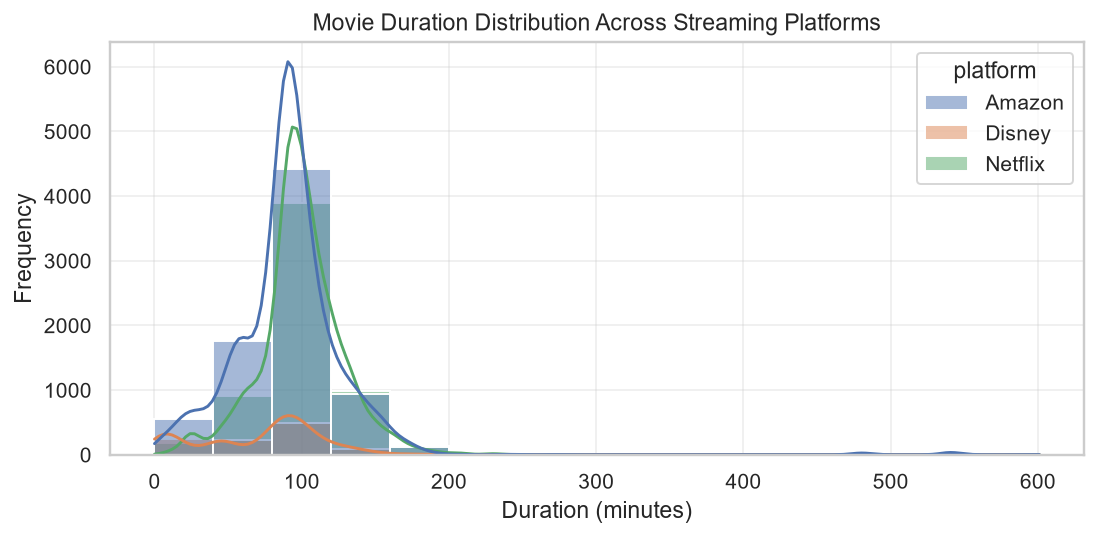

In [24]:
# Compare movie duration distributions across streaming platforms

movie_duration_df = streaming_df.query('type == "Movie"')

# Visualize
plt.figure(figsize=(8,4))

sns.histplot(
    data=movie_duration_df,
    x='duration_numeric',
    hue='platform',
    bins=15,
    kde=True   
)

format_plot(
    'Movie Duration Distribution Across Streaming Platforms',
    'Duration (minutes)',
    'Frequency'
)


Movie lengths are **concentrated mainly between 90 and 120 minutes** across all platforms. **Amazon and Netflix** follow **very similar patterns**, while **Disney+** skews **slightly shorter**.

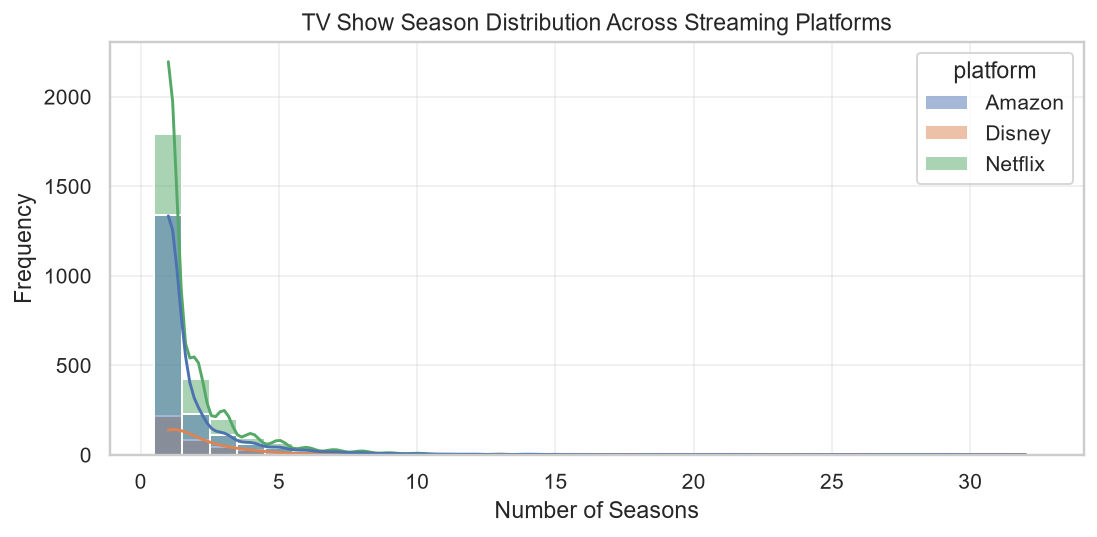

In [25]:
# Compare TV Show season distributions across streaming platforms

tvshows_duration_df = streaming_df.query('type == "TV Show"')

# Visualize
plt.figure(figsize=(8,4))

sns.histplot(
    data=tvshows_duration_df,
    x='duration_numeric',
    hue='platform',
    bins=20,
    kde=True,
    discrete=True
)

format_plot(
    'TV Show Season Distribution Across Streaming Platforms',
    'Number of Seasons',
    'Frequency'
)


Most TV shows on all platforms have only **one or two seasons**. **Titles with five or more seasons are rare**, which shows that short-run series remain the standard format. This pattern reflects a streaming environment where quick and frequent releases often matter more than long-running franchises.

<Figure size 1120x560 with 0 Axes>

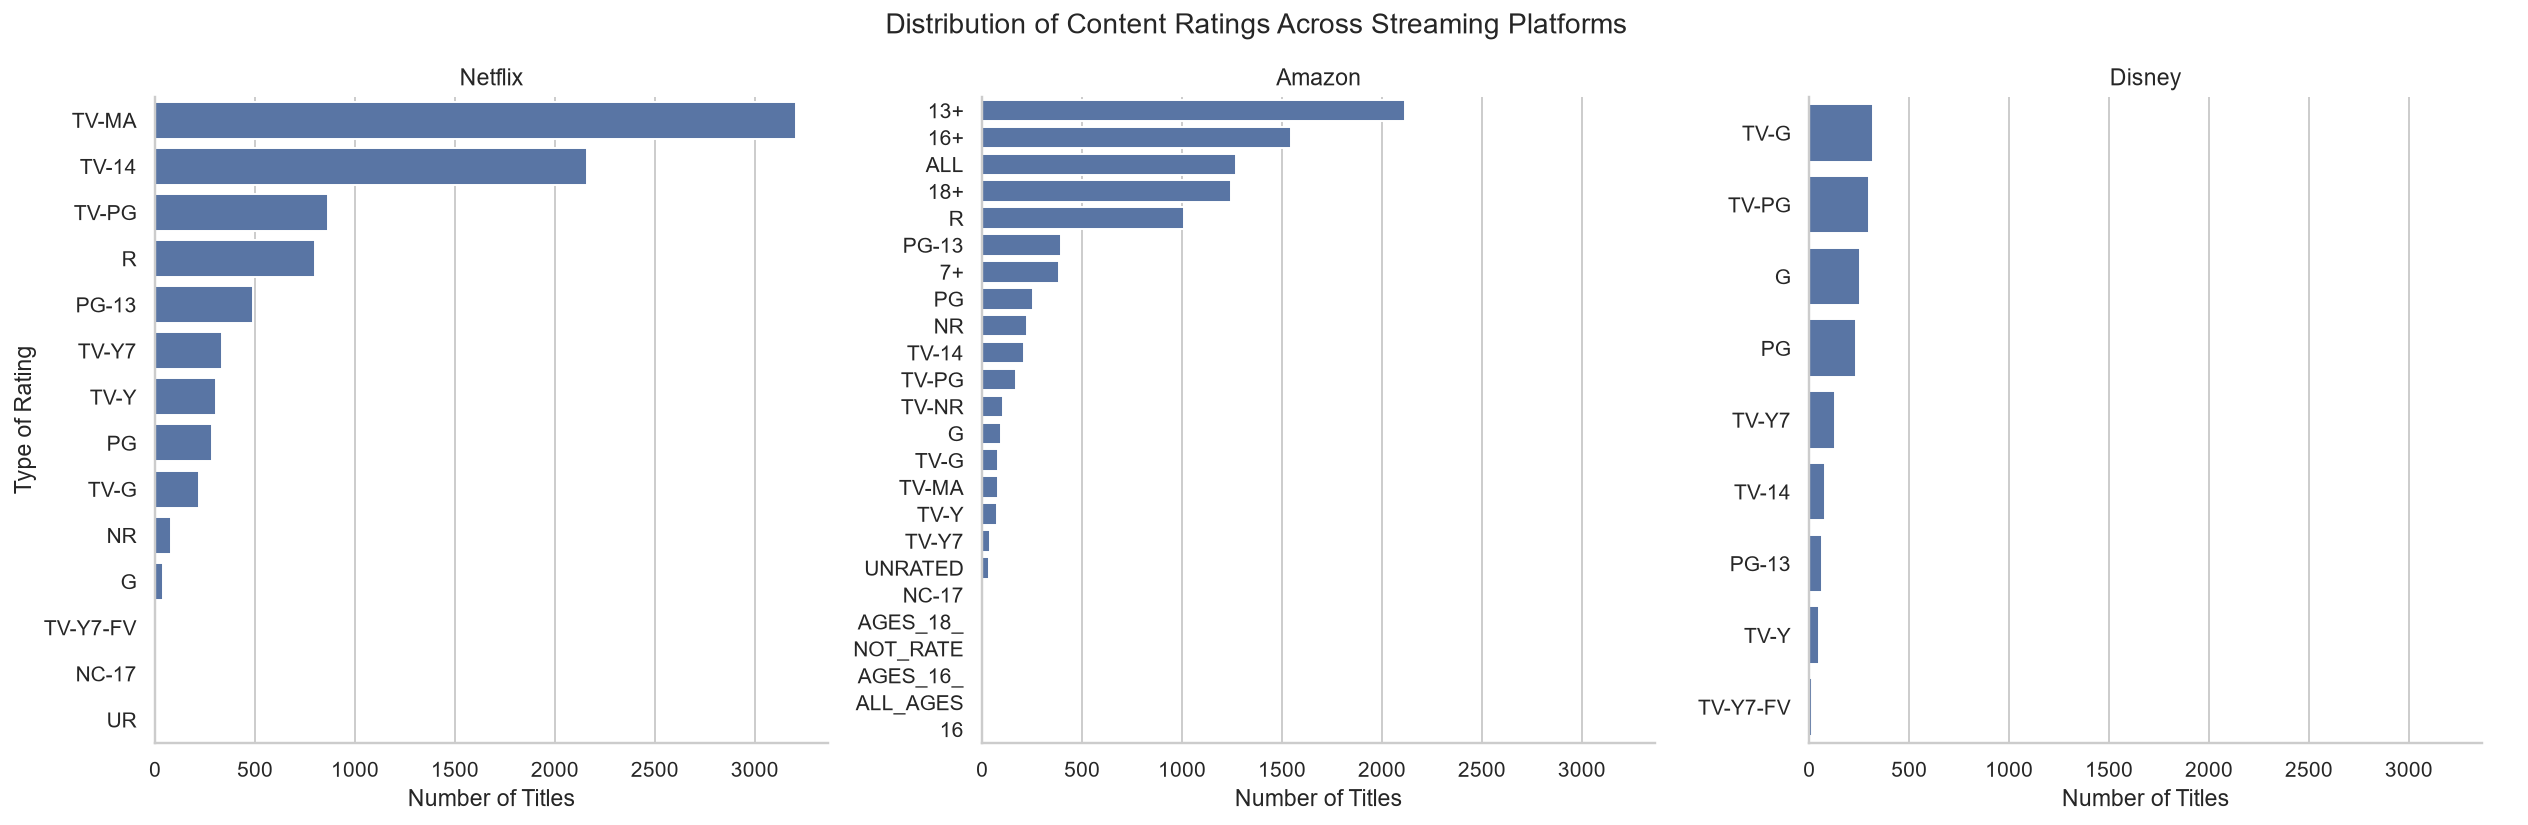

In [26]:
# Compare content ratings by platform

platform_rating_counts = (
    streaming_df.query('rating != "Unknown"')
    ).groupby(['platform', 'rating']).size().reset_index(name='count').sort_values('count', ascending=False)

# Visualize
plt.figure(figsize=(8,4))

g = sns.catplot(
    data=platform_rating_counts,
    x='count',
    y='rating',
    col='platform',
    kind='bar',
    height=6,
    aspect=1,
    sharey=False,
)

# Main title
g.fig.suptitle("Distribution of Content Ratings Across Streaming Platforms")

# Subtitle for each subplot
g.set_titles("{col_name}")
g.set_axis_labels('Number of Titles', 'Type of Rating')

g.fig.subplots_adjust(top=0.88)
g.savefig(f"images/Distribution of Content Ratings Across Streaming Platforms.png", dpi=300, bbox_inches="tight")
plt.show()


**Netflix's** most frequent rating is **TV-MA**, indicating a focus on adult content. **Amazon's** top rating is **13+** or its equivalent, and **Disney+** is overwhelmingly family-friendly, with **TV-G** as its most common rating. This clearly reflects the target audience for each service. Netflix targets adults, Amazon has a broad appeal to teenagers and adults, and Disney+ is designed for families and children.

C:\Users\User\AppData\Local\Temp\ipykernel_23520\2285630562.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


<Figure size 1120x560 with 0 Axes>

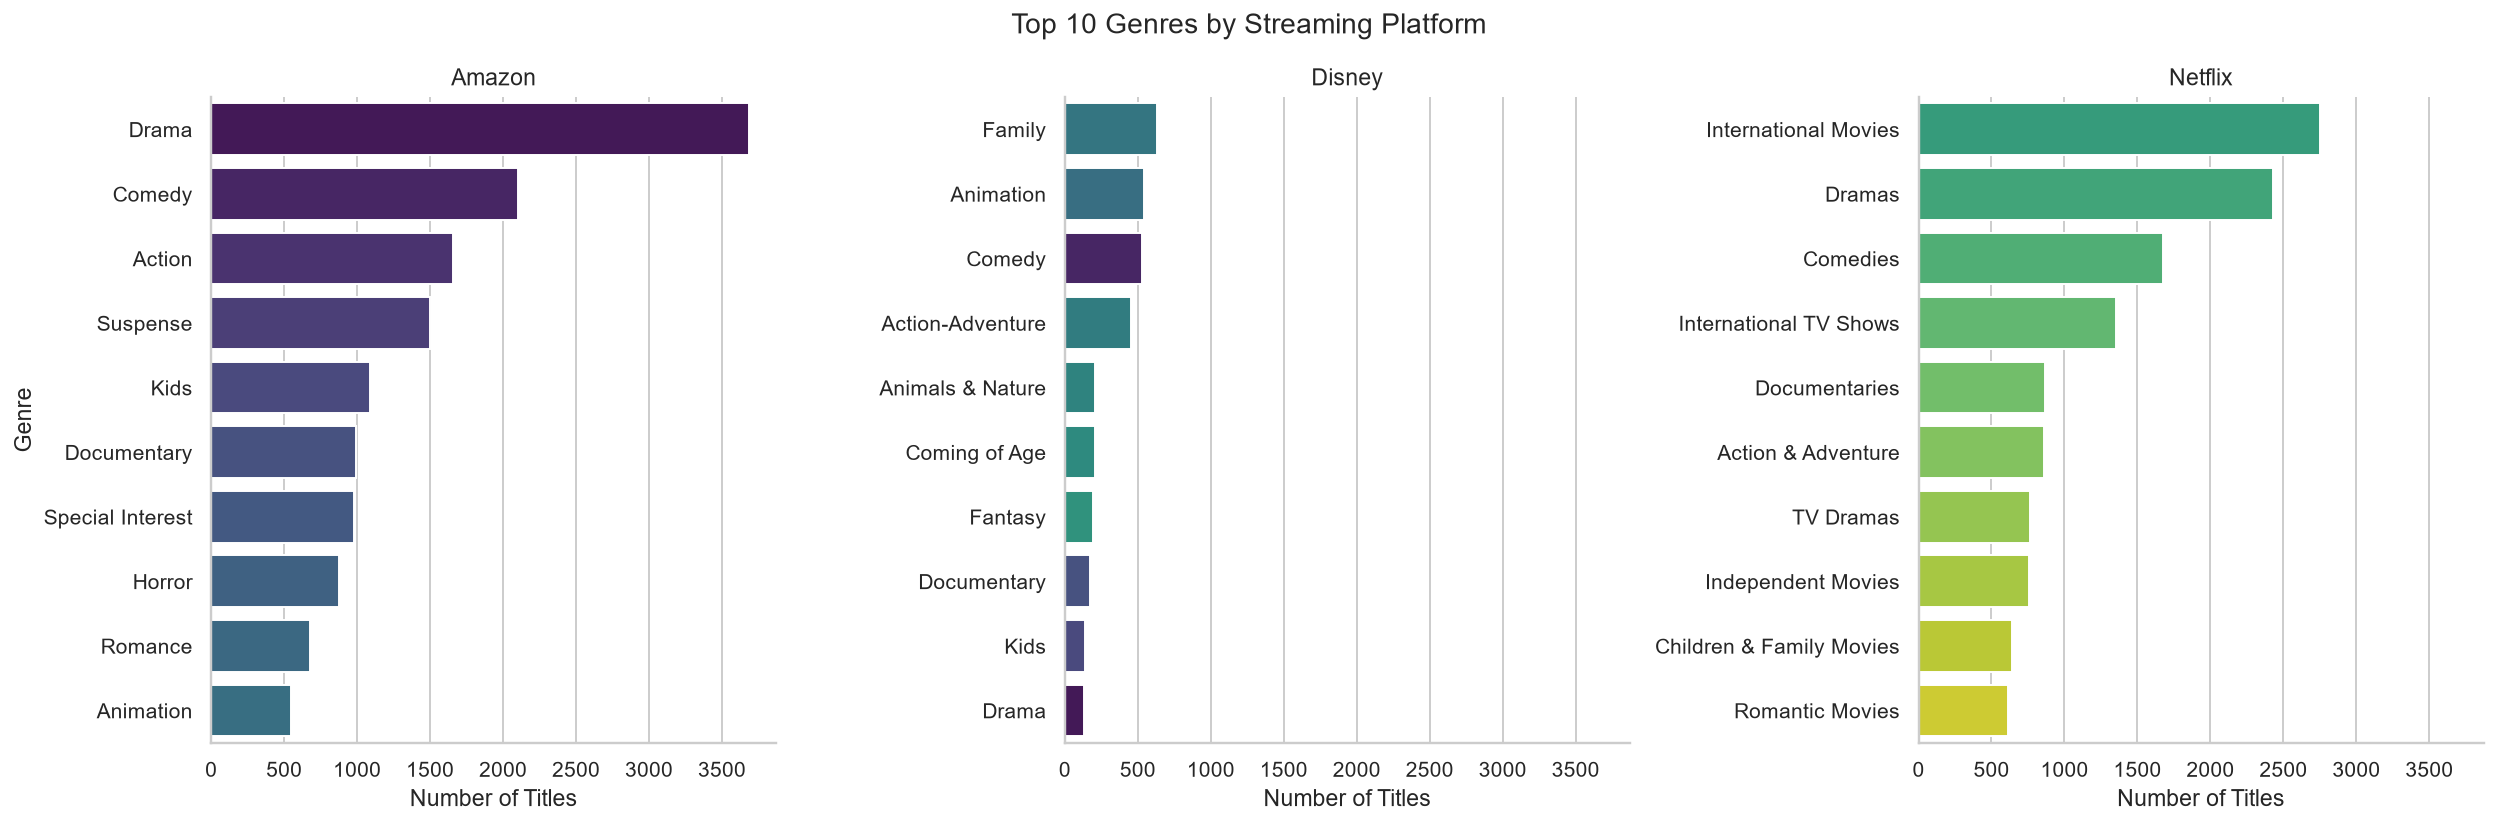

In [27]:
# Identify the top 10 most common genres across streaming platforms

# Split the listed_in column into individual genres
platform_genre_df = (
    streaming_df
    .assign(
        genre=streaming_df['listed_in']
        .str.split(',')
    )
    .explode('genre')
)

# Clean whitespace
platform_genre_df['genre'] = platform_genre_df['genre'].str.strip()

# Count titles by platform, genre, and content type
genre_counts = (
    platform_genre_df
    .groupby(['platform', 'genre'])
    .size()
    .reset_index(name='count')
)

# Keep only the Top 10 genres for each platform
top_genre_data = (
    genre_counts
    .sort_values(['platform', 'count'], ascending=[True, False])
    .groupby('platform')
    .head(10)
)

# Visualize
plt.figure(figsize=(8,4))

g = sns.catplot(
    data=top_genre_data,
    x='count',
    y='genre',
    col='platform',
    kind='bar',
    palette='viridis',
    height=6,
    aspect=1,
    sharey=False
)

# Main title
g.fig.suptitle("Top 10 Genres by Streaming Platform")

# Subtitle for each subplot
g.set_titles("{col_name}")
g.set_axis_labels('Number of Titles', 'Genre')

g.fig.subplots_adjust(top=0.88)
g.savefig(f"images/Top 10 Genres by Streaming Platform.png", dpi=300, bbox_inches="tight")
plt.show()



**Drama** is the most represented genre on **Amazon Prime**, while **Netflix** shows a broader mix of **International Movies**, **Dramas**, and other popular genres. **Disney+** differs noticeably by featuring a larger proportion of **Family** and **Animation** titles than the other platforms. Overall, the genre distributions indicate that each streaming platform offers a distinct mix of content categories.

C:\Users\User\AppData\Local\Temp\ipykernel_23520\2161927928.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


<Figure size 1120x560 with 0 Axes>

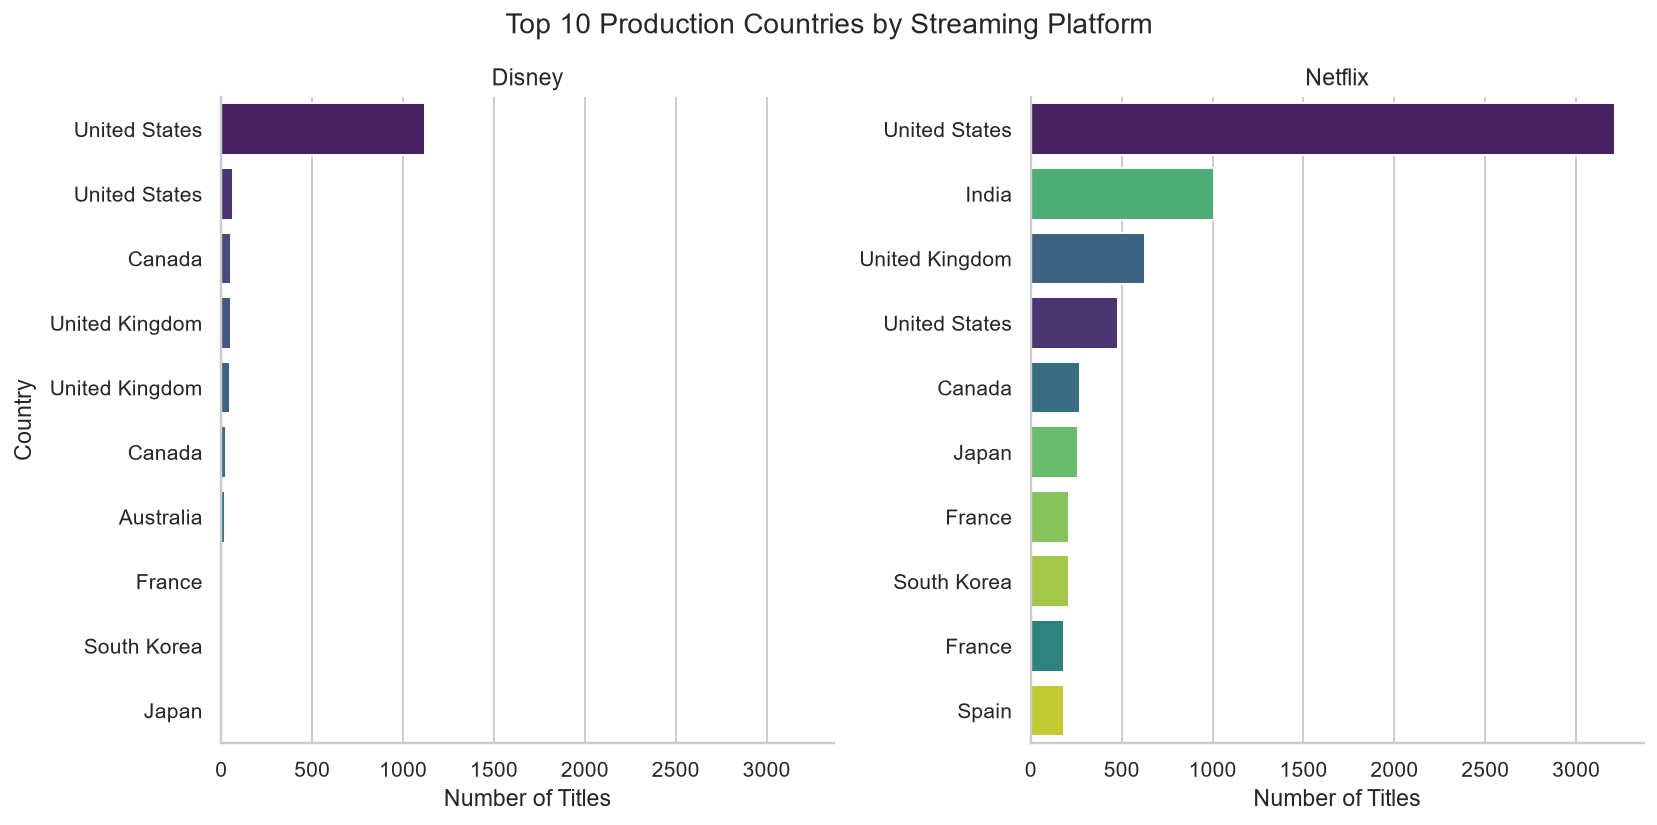

In [28]:
# Identify the top 10 producing countries across streaming platforms

top_countries = (
    streaming_df.query('platform != "Amazon"')
    .assign(countries=lambda df: df['country'].str.split(','))
    .explode('countries')
    .reset_index(drop=True)
    .query('countries != "Unknown"')
    .groupby(['platform', 'countries'])
    .size()
    .reset_index(name='count')
    .sort_values(['platform', 'count'], ascending=[True, False])
    .groupby('platform', group_keys=False)
    .head(10)                     # Top 10 per platform
    .reset_index(drop=True)
)

# Visualize
plt.figure(figsize=(8,4))

g = sns.catplot(
    data=top_countries,
    x='count',
    y='countries',
    col='platform',
    kind='bar',
    palette='viridis',
    height=6,
    aspect=1,
    sharey=False
)

# Main title
g.fig.suptitle("Top 10 Production Countries by Streaming Platform")

# Subtitle for each subplot
g.set_titles("{col_name}")
g.set_axis_labels('Number of Titles', 'Country')

g.fig.subplots_adjust(top=0.88)
g.savefig(f"images/Top 10 Production Countries by Streaming Platform.png", dpi=300, bbox_inches="tight")
plt.show()


The **United States** contributes the largest number of titles across both **Netflix** and **Disney+**. However, **Netflix** also includes a broader range of production countries, with **India**, the **United Kingdom**, and **Canada** appearing prominently among its top contributors. In comparison, **Disney+** has a more concentrated distribution of production countries, indicating lower geographic diversity within its available catalog.

> **Note:** **Amazon Prime** was excluded from this analysis because **93.05%** of its records contain missing values in the **`country`** field. Including these records would introduce substantial bias and reduce the reliability of cross-platform comparisons.

C:\Users\User\AppData\Local\Temp\ipykernel_23520\2797894783.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


<Figure size 1120x560 with 0 Axes>

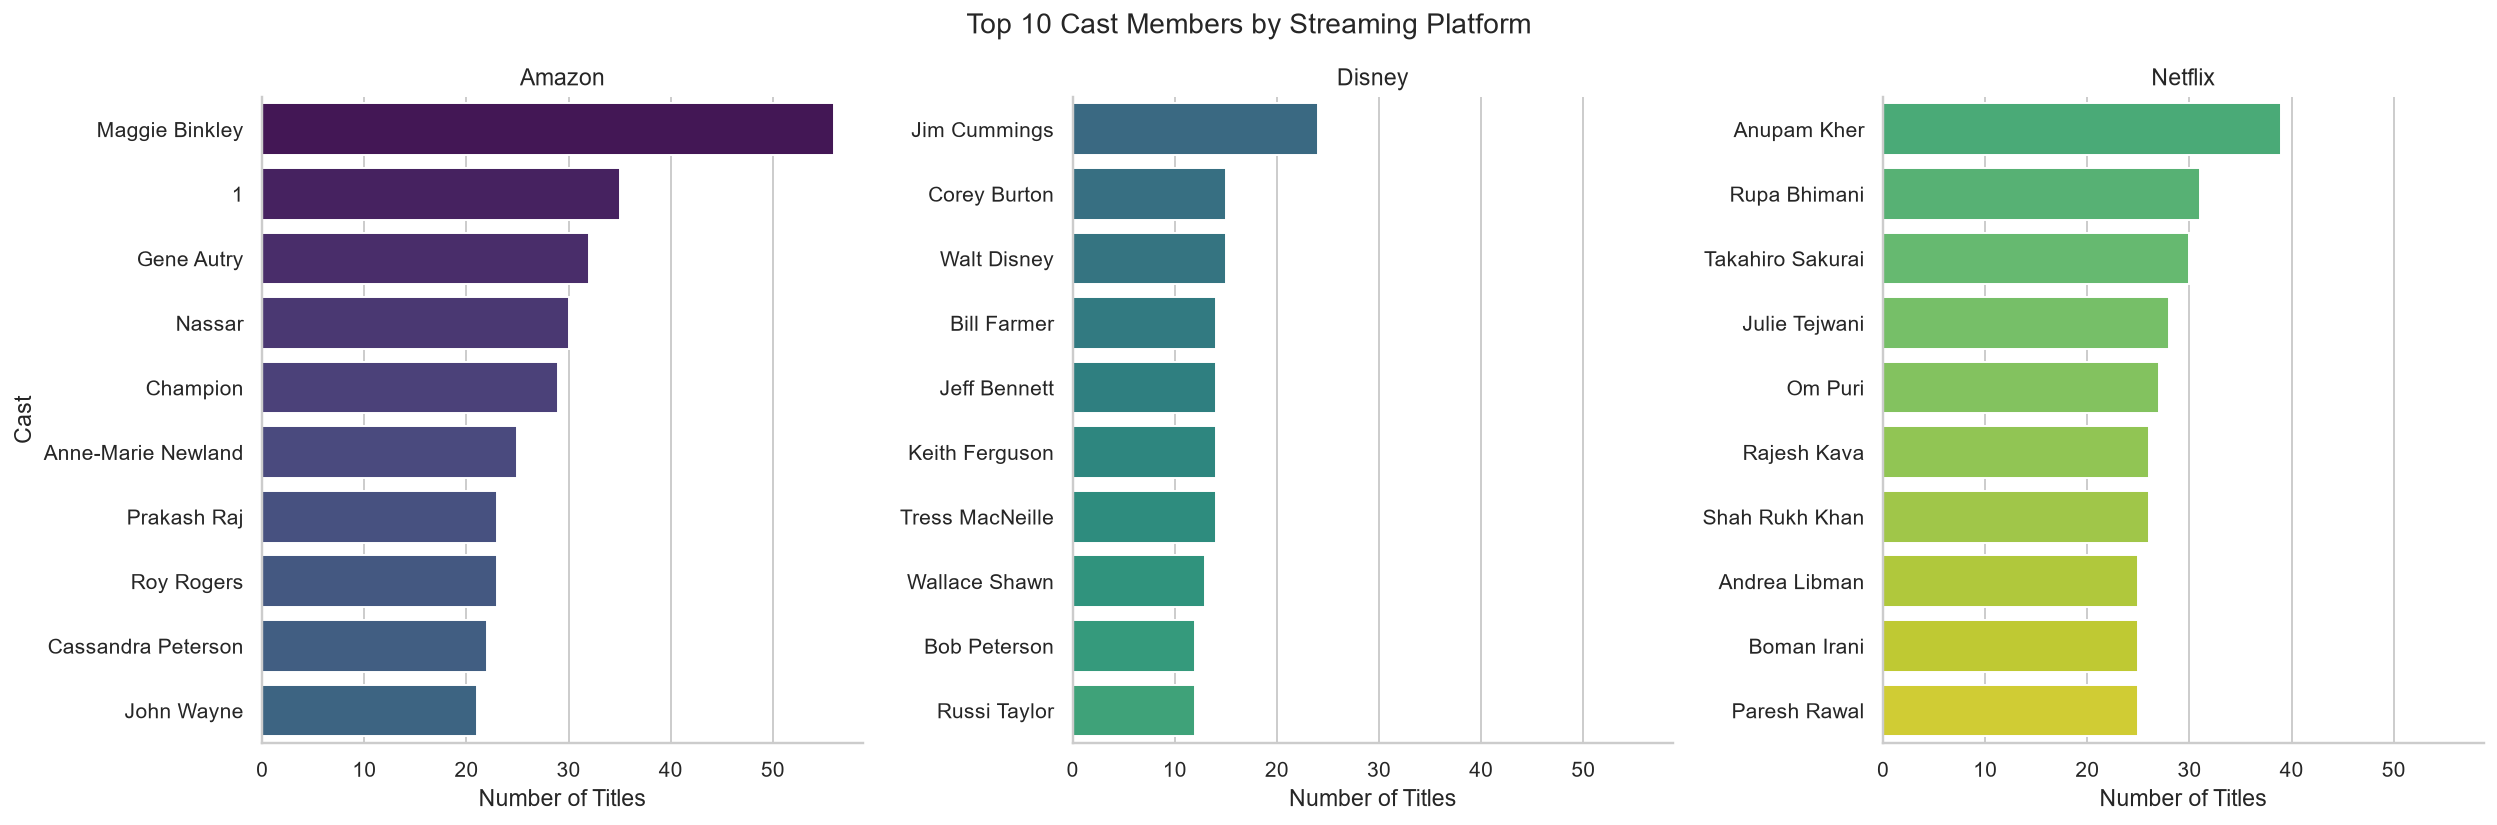

In [29]:
# Identify the top 10 actors with high contribution across streaming platforms

top_cast_members = (
    streaming_df.query('cast != "Unknown"')
    .assign(cast=lambda df: df['cast'].str.split(','))
    .explode('cast')
    .reset_index(drop=True)
    .groupby(['platform', 'cast'])
    .size()
    .reset_index(name='count')
    .sort_values(['platform', 'count'], ascending=[True, False])
    .groupby('platform', group_keys=False)
    .head(10)
    .reset_index(drop=True)
)

# Visualize
plt.figure(figsize=(8,4))

g = sns.catplot(
    data=top_cast_members,
    x='count',
    y='cast',
    col='platform',
    kind='bar',
    palette='viridis',
    height=6,
    aspect=1,
    sharey=False
)

# Main title
g.fig.suptitle('Top 10 Cast Members by Streaming Platform')

# Subtitle for each subplot
g.set_titles('{col_name}')
g.set_axis_labels('Number of Titles', 'Cast')

g.savefig(f"images/Top 10 Cast Members by Streaming Platform.png", dpi=300, bbox_inches="tight")
g.fig.subplots_adjust(top=0.88)
plt.show()


**Netflix's** most frequently appearing cast members include **Anupam Kher** and **Rupa Bhimani**, while **Disney+** is led by performers such as **Jim Cummings** and **Corey Burton**. **Amazon Prime** features **Maggie Binkley** among its most recurring cast members. The variation in frequently appearing cast members across platforms reflects differences in the titles available within each streaming catalog rather than a shared group of recurring performers.

C:\Users\User\AppData\Local\Temp\ipykernel_23520\2820602705.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


<Figure size 1120x560 with 0 Axes>

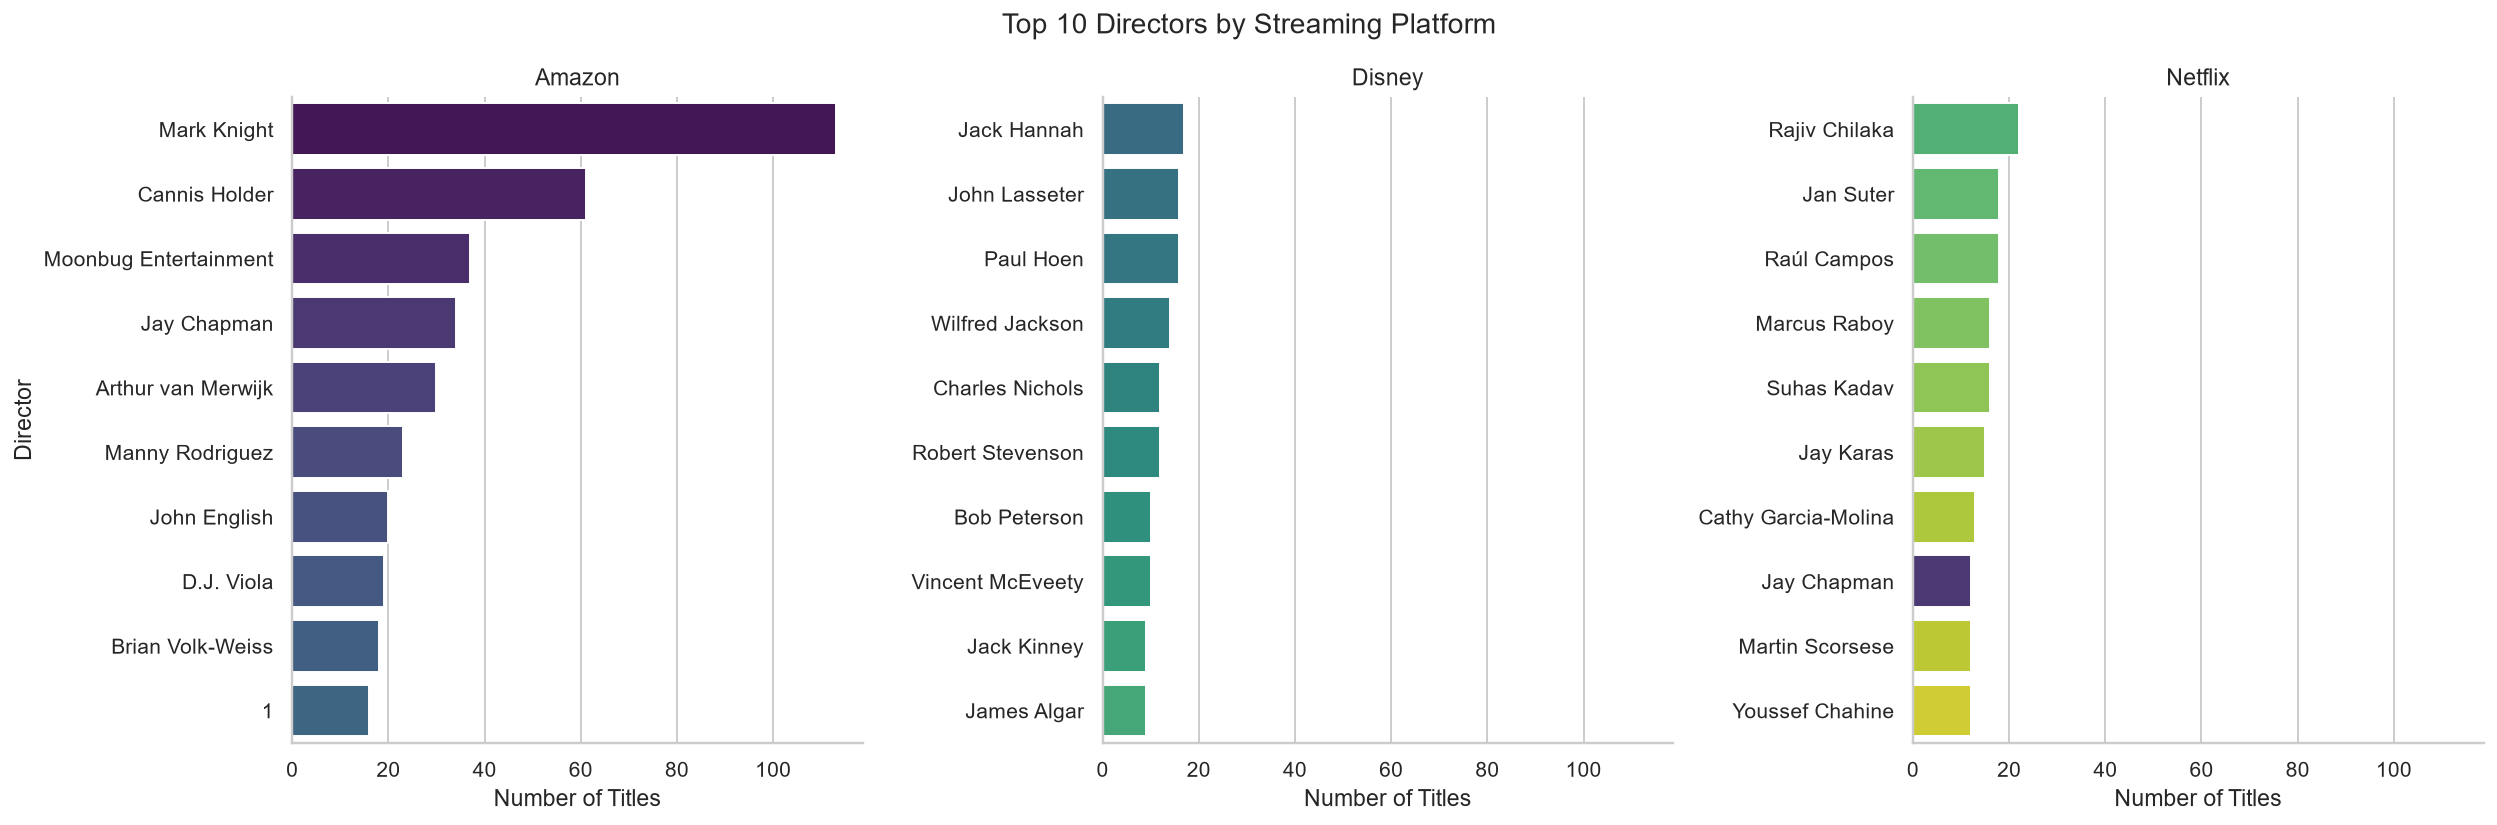

In [30]:
# Identify the top 10 directors with high released title across streaming platforms

top_directors = (
    streaming_df.query('director != "Unknown"')
    .assign(director=lambda df: df['director'].str.split(','))
    .explode('director')
    .reset_index(drop=True)
    .groupby(['platform', 'director'])
    .size()
    .reset_index(name='count')
    .sort_values(['platform', 'count'], ascending=[True, False])
    .groupby('platform', group_keys=False)
    .head(10)
    .reset_index(drop=True)
)

# Visualize
plt.figure(figsize=(8,4))

g = sns.catplot(
    data=top_directors,
    x='count',
    y='director',
    col='platform',
    kind='bar',
    palette='viridis',
    height=6,
    aspect=1,
    sharey=False
)

# Main title
g.fig.suptitle('Top 10 Directors by Streaming Platform')

# Subtitle for each subplot
g.set_titles('{col_name}')
g.set_axis_labels('Number of Titles', 'Director')

g.savefig(f"images/Top 10 Directors by Streaming Platform.png", dpi=300, bbox_inches="tight")
g.fig.subplots_adjust(top=0.88)
plt.show()


**Netflix's** most frequently appearing directors include **Rajiv Chilaka**, while **Disney+** features directors such as **Jack Hannah** and **John Lasseter**. **Amazon Prime** is led by **Mark Knight**, alongside several other recurring directors. Overall, the most frequently appearing directors differ across platforms, highlighting variations in the composition of their available content libraries.

## Cross-Platform Summary

In [31]:
# Cross-Platform Summary

summary = pd.DataFrame(index=[
    'Total Titles',
    'Movies',
    'TV Shows',
    'Avg Release Year',
    'Most Common Rating',
    'Most Common Genre',
    'Avg Movie Duration (min)',
    'Avg TV Show Duration'         
])

platforms = ['Netflix', 'Amazon', 'Disney']

for platform in platforms:
    df_p = streaming_df[streaming_df['platform'] == platform].copy()
    
    # Convert release_year to numeric
    df_p['release_year'] = pd.to_numeric(df_p['release_year'], errors='coerce')
    
    total = len(df_p)
    movies = len(df_p[df_p['type'] == 'Movie'])
    tvshows = len(df_p[df_p['type'] == 'TV Show'])
    
    avg_year = round(df_p['release_year'].mean(), 1) if not df_p['release_year'].isna().all() else np.nan
    
    # Most Common Rating & Genre
    most_rating = df_p['rating'].mode().iloc[0] if not df_p['rating'].empty else '-'
    most_genre = (df_p['listed_in'].str.split(',').explode().str.strip()).mode().iloc[0] 
    
    # Duration using duration_numeric 
    # Movies
    movie_titles_df = df_p[df_p['type'] == 'Movie']
    avg_movie_duration = round(movie_titles_df['duration_numeric'].mean(), 1) if not movie_titles_df.empty else np.nan
    
    # TV Shows
    tv_show_df = df_p[df_p['type'] == 'TV Show']
    avg_tv_duration = round(tv_show_df['duration_numeric'].mean(), 1) if not tv_show_df.empty else np.nan
    
    summary[platform] = [
        total,
        movies,
        tvshows,
        avg_year,
        most_rating,
        most_genre,
        avg_movie_duration,
        avg_tv_duration
    ]

# Final formatting
summary = summary.fillna('-').astype(str)

display(summary)

,Netflix,Amazon,Disney
Total Titles,8807,9668,1450
Movies,6131,7814,1052
TV Shows,2676,1854,398
Avg Release Year,2014.2,2008.3,2003.1
Most Common Rating,TV-MA,13+,TV-G
Most Common Genre,International Movies,Drama,Family
Avg Movie Duration (min),99.6,91.3,71.9
Avg TV Show Duration,1.8,1.7,2.1


The comparative analysis reveals clear differences in the content libraries of **Netflix**, **Amazon Prime**, and **Disney+**. While **Amazon Prime** contains the largest catalog, **Netflix** maintains the largest collection of TV Shows and a more geographically diverse set of production countries. In contrast, **Disney+** offers a smaller catalog characterized by a higher proportion of **Family** and **Animation** content.

Despite these differences, all three platforms share several common characteristics. Movies account for the majority of available titles, most TV Shows consist of a single season, and standard feature-length movies are the most common across platforms. These findings provide a high-level overview of how the streaming services differ in catalog composition while highlighting several consistent trends across their content libraries.

# Conclusions and Recommendations

## Conclusions

- **Amazon Prime Video** contains the largest content library, while **Netflix** offers the largest collection of TV Shows among the analyzed platforms, highlighting differences in their content acquisition strategies.
- Movies consistently outnumber TV Shows across all platforms, indicating that films make up the majority of available streaming content.
- Genre and content rating distributions vary across platforms. **Disney+** shows a stronger concentration of **Family** and **Animation** titles, while **Netflix** and **Amazon Prime Video** provide a broader mix of genres and ratings.
- Most TV Shows consist of a single season, and movie durations remain relatively consistent across all platforms.
- Metadata completeness differs across the datasets, particularly for **Amazon Prime Video**, emphasizing the importance of assessing data quality before performing comparative analyses.

## Recommendations

- Integrate external datasets such as **IMDb** or **TMDb** to enrich the analysis with audience ratings, popularity scores, vote counts, and financial performance metrics.
- Improve data quality by validating and completing missing metadata before conducting comparative analyses to produce more reliable insights.
- Extend the comparison by including additional streaming platforms and more recent datasets to better reflect the current streaming landscape.
- Build interactive dashboards or predictive models, such as recommendation systems or genre classification models, to support deeper analysis and data-driven decision-making.